## T2 - Geolocalização e Mapas Digitais

# Integrantes:
- Igor Improta Martinez da Silva | RA: 21.00834-5
- Lucas Gozze Crapino | RA: 22.00667-2
- Murillo Penha Strina | RA: 22.00730-0

## Parte 1: Setup e recuperação dos dados

In [5]:
!pip install pydeck osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.7 MB/s eta 0:00:00


In [10]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import osmnx as ox
import matplotlib.pyplot as plt
import pydeck as pdk
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. Carregando os dados
df = pd.read_csv('Ubereat_US_Merchant.csv')
df_al = df[df['state'] == 'AL'].copy()

# Excluindo APENAS quem não tem lat/lon (porque sem coordenada não tem mapa)
df_al = df_al.dropna(subset=['latitude', 'longitude'])

# 2. IMPUTAÇÃO DE DADOS (A mágica para não perder os 267 restaurantes)
# Primeiro garantimos que as colunas são numéricas
df_al['delivery_fee'] = pd.to_numeric(df_al['delivery_fee'], errors='coerce')
df_al['review_rating'] = pd.to_numeric(df_al['review_rating'], errors='coerce')

# Preenchemos as taxas vazias com a mediana do estado (ex: $2.49)
mediana_taxa = df_al['delivery_fee'].median()
df_al['delivery_fee'] = df_al['delivery_fee'].fillna(mediana_taxa)

# Preenchemos as notas vazias com a mediana do estado (ex: 4.5)
mediana_nota = df_al['review_rating'].median()
df_al['review_rating'] = df_al['review_rating'].fillna(mediana_nota)

# 3. Criando o GeoDataFrame
df_al['geometry'] = df_al.apply(lambda row: Point(row['longitude'], row['latitude']), axis=1)
gdf_rest = gpd.GeoDataFrame(df_al, geometry='geometry', crs="EPSG:4326")

# 4. Recortando pelo polígono de Birmingham
cidade = 'Birmingham, Alabama, USA'
city_polygon = ox.geocode_to_gdf(cidade).geometry.iloc[0]
gdf_birmingham = gdf_rest[gdf_rest.geometry.within(city_polygon)].copy()

print(f"Base de dados tratada com sucesso! Total de restaurantes aptos: {len(gdf_birmingham)}")

Base de dados tratada com sucesso! Total de restaurantes aptos: 268


## Parte 2: Análise espacial e Custo-Benefício

In [12]:
# INTELIGÊNCIA DE MERCADO: Métrica de "Joia Escondida" (Alto Custo-Benefício)

# 1. Limpando a coluna de preços (removendo espaços ocultos em branco)
gdf_birmingham['price_bucket_limpo'] = gdf_birmingham['price_bucket'].astype(str).str.strip()

# 2. Nova Regra Dinâmica e Realista:
# - Nota >= 4.0 (Uma nota excelente)
# - Taxa de entrega MENOR OU IGUAL à mediana da própria região (Garante que é "abaixo da média" local)
# - Preço Barato ($) ou Moderado ($$)
condicao_joia = (
    (gdf_birmingham['review_rating'] >= 4.0) &
    (gdf_birmingham['delivery_fee'] <= mediana_taxa) &
    (gdf_birmingham['price_bucket_limpo'].isin(['$', '$$']))
)
gdf_birmingham['joia_escondida'] = condicao_joia

# Estatísticas para o relatório
total = len(gdf_birmingham)
joias = len(gdf_birmingham[gdf_birmingham['joia_escondida']])
# Somando os valores True
em_residencial = gdf_birmingham['em_residencial'].sum()

print(f"\n--- Resultados da Análise ---")
print(f"Total de Restaurantes: {total}")
print(f"Localizados em Zonas Residenciais: {em_residencial} ({(em_residencial/total)*100:.1f}%)")
print(f"'Joias Escondidas' (Alto Custo-Benefício): {joias} ({(joias/total)*100:.1f}%)")


--- Resultados da Análise ---
Total de Restaurantes: 268
Localizados em Zonas Residenciais: 30 (11.2%)
'Joias Escondidas' (Alto Custo-Benefício): 205 (76.5%)


## Parte 3: Projeções (Mapa Estático)

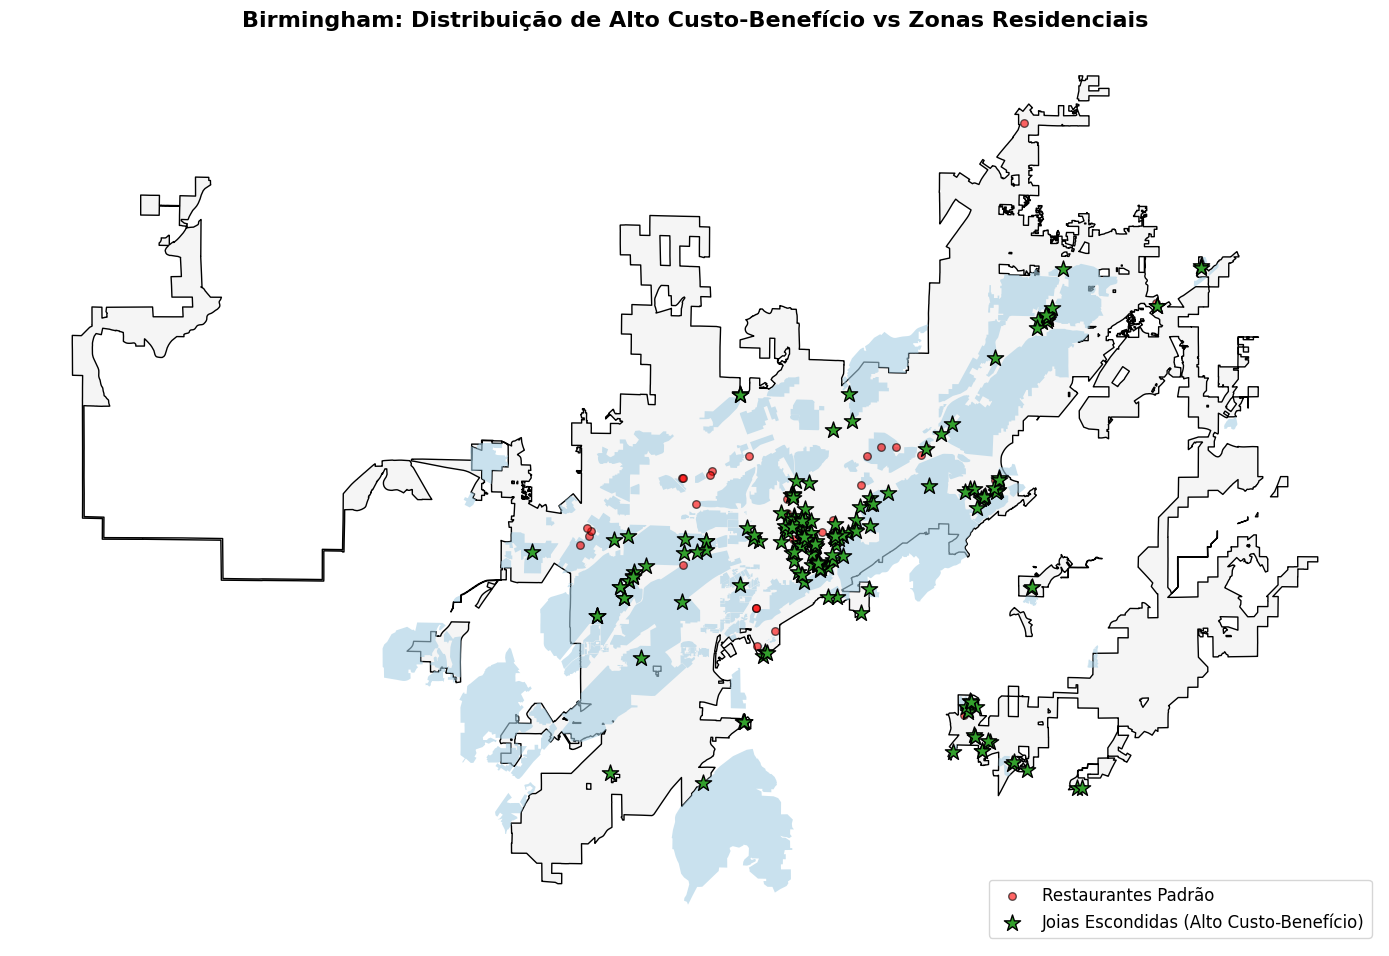

In [14]:
fig, ax = plt.subplots(figsize=(14, 14))

# 1. Plotando o limite da cidade
ox.geocode_to_gdf(cidade).plot(ax=ax, color='whitesmoke', edgecolor='black', linewidth=1)

# 2. Plotando as Zonas Residenciais (Fundo Cinza/Azulado)
residenciais.plot(ax=ax, color='#a6cee3', alpha=0.6, label='Zonas Residenciais')

# 3. Plotando Restaurantes Padrão (Vermelho)
comuns = gdf_birmingham[~gdf_birmingham['joia_escondida']]
comuns.plot(ax=ax, color='red', markersize=30, alpha=0.6, label='Restaurantes Padrão', edgecolor='black')

# 4. Plotando as Joias Escondidas (Estrelas Verdes)
joias_gdf = gdf_birmingham[gdf_birmingham['joia_escondida']]
joias_gdf.plot(ax=ax, color='#33a02c', markersize=150, marker='*', edgecolor='black',
               label='Joias Escondidas (Alto Custo-Benefício)')

# Ajustes visuais
plt.title('Birmingham: Distribuição de Alto Custo-Benefício vs Zonas Residenciais', fontsize=16, fontweight='bold')
ax.axis('off')

# Criando legenda personalizada
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles=handles, labels=labels, loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

## Parte 4: Projeções (Mapa Hexagonal 3D)

In [15]:
from IPython.display import HTML

# Preparando os dados para o Pydeck (remover a coluna 'geometry' do GeoPandas)
df_pdk = pd.DataFrame(gdf_birmingham.drop(columns=['geometry']))

# Configurando o ângulo e centro da câmera (Pitch 45 para dar o efeito 3D)
view = pdk.ViewState(
    latitude=city_polygon.centroid.y,
    longitude=city_polygon.centroid.x,
    zoom=11.5,
    pitch=45
)

# HexagonLayer: A ALTURA do hexágono vai representar a quantidade de restaurantes naquela quadra
layer = pdk.Layer(
    "HexagonLayer",
    df_pdk,
    get_position=["longitude", "latitude"],
    auto_highlight=True,
    elevation_scale=50,       # Multiplicador da altura do gráfico 3D
    pickable=True,
    elevation_range=[0, 1000],
    extruded=True,            # Ativa o 3D
    coverage=1,
)

# Montando o mapa e adicionando um tooltip (balão) ao passar o mouse
mapa_3d = pdk.Deck(
    layers=[layer],
    initial_view_state=view,
    tooltip={"text": "Densidade: {elevationValue} restaurantes nesta área"}
)

# Salvando e renderizando o HTML no Colab
arquivo_hex = 'mapa_densidade_hexagonal.html'
mapa_3d.to_html(arquivo_hex)

print("Mapa 3D Gerado! Passe o mouse sobre os hexágonos e use o botão direito para rotacionar o mapa em 3D:")
display(HTML(filename=arquivo_hex))

<IPython.core.display.Javascript object>

Mapa 3D Gerado! Passe o mouse sobre os hexágonos e use o botão direito para rotacionar o mapa em 3D:


## Parte 5: Exportação dos dados (Formato JSON)

In [17]:
from google.colab import files

# Salvando o GeoDataFrame tratado contendo as colunas de "joia_escondida" e "em_residencial"
arquivo_json = 'dados_birmingham_tratados.json'

# O formato GeoJSON é um arquivo JSON legítimo estruturado para coordenadas espaciais
gdf_birmingham.to_file(arquivo_json, driver='GeoJSON')

print(f"Arquivo '{arquivo_json}' gerado com sucesso! Iniciando o download automático...")

# Força o download do arquivo para a sua máquina
files.download(arquivo_json)

Arquivo 'dados_birmingham_tratados.json' gerado com sucesso! Iniciando o download automático...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>